# Loan Approval Prediction System
### Data Science Mini Project

**Domains:** Financial Analytics (DS) &nbsp;|&nbsp; Approval Prediction (ML) &nbsp;|&nbsp; Credit Evaluation (AI)

This notebook builds an end-to-end pipeline that predicts whether a bank loan application will be **Approved** or **Rejected**, based on applicant financial and demographic data.

**Pipeline:**
1. Data Loading & Cleaning
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Model Training (Logistic Regression, Decision Tree, Random Forest)
5. Model Evaluation & Comparison
6. Feature Importance & Business Insights
7. Save Final Model

## 1. Data Loading & Cleaning

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Load dataset
df = pd.read_csv('loan_approval_dataset.csv')

# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Remove leading/trailing spaces from all text columns
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = df[col].str.strip()

print("Shape:", df.shape)
df.head()

Shape: (4269, 13)


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [18]:
df.info()
print("\nMissing values:\n", df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   loan_id                   4269 non-null   int64
 1   no_of_dependents          4269 non-null   int64
 2   education                 4269 non-null   str  
 3   self_employed             4269 non-null   str  
 4   income_annum              4269 non-null   int64
 5   loan_amount               4269 non-null   int64
 6   loan_term                 4269 non-null   int64
 7   cibil_score               4269 non-null   int64
 8   residential_assets_value  4269 non-null   int64
 9   commercial_assets_value   4269 non-null   int64
 10  luxury_assets_value       4269 non-null   int64
 11  bank_asset_value          4269 non-null   int64
 12  loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 433.7 KB

Missing values:
 loan_id                     0
no_of_depend

In [20]:
# A few residential_assets_value entries are negative (data-entry artifact) -> clip to 0
print("Negative residential_assets_value rows:", (df['residential_assets_value'] < 0).sum())
df['residential_assets_value'] = df['residential_assets_value'].clip(lower=0)

df['loan_status'].value_counts()

Negative residential_assets_value rows: 0


loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

## 2. Exploratory Data Analysis (EDA)

We look at class balance, how CIBIL score separates approved vs rejected applicants, the relationship between income and loan amount, correlations between numeric features, and whether education/self-employment affect approval odds.

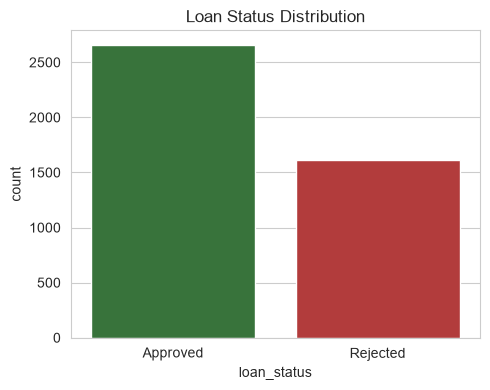

In [21]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='loan_status', hue='loan_status', palette=['#2E7D32','#C62828'], legend=False)
plt.title('Loan Status Distribution')
plt.tight_layout()
plt.show()

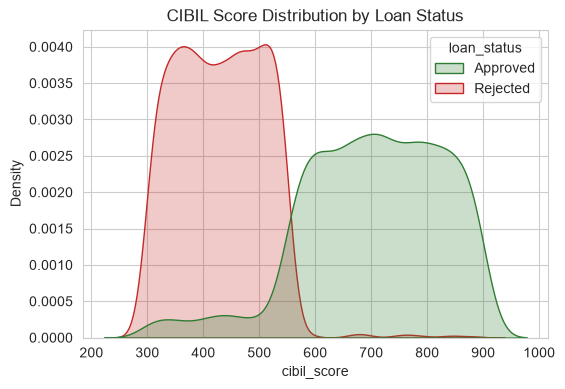

Approved applicants CIBIL range: 300-900
Rejected applicants CIBIL range: 300-885


In [22]:
plt.figure(figsize=(6,4))
sns.kdeplot(data=df, x='cibil_score', hue='loan_status', fill=True, common_norm=False, palette=['#2E7D32','#C62828'])
plt.title('CIBIL Score Distribution by Loan Status')
plt.show()

approved_min = df[df.loan_status=='Approved']['cibil_score'].min()
rejected_max = df[df.loan_status=='Rejected']['cibil_score'].max()
print(f"Approved applicants CIBIL range: {approved_min}-{df[df.loan_status=='Approved']['cibil_score'].max()}")
print(f"Rejected applicants CIBIL range: {df[df.loan_status=='Rejected']['cibil_score'].min()}-{rejected_max}")

>**Insight:** CIBIL score is a strong separator — approved applicants average **~703**, rejected average **~429**. This will likely dominate the model's decision.

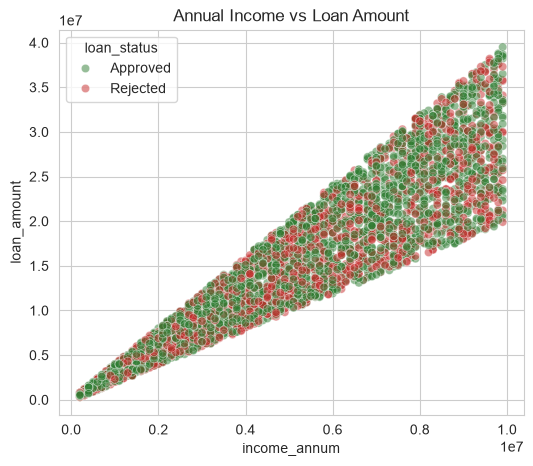

In [23]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x='income_annum', y='loan_amount', hue='loan_status', alpha=0.5, palette=['#2E7D32','#C62828'])
plt.title('Annual Income vs Loan Amount')
plt.show()

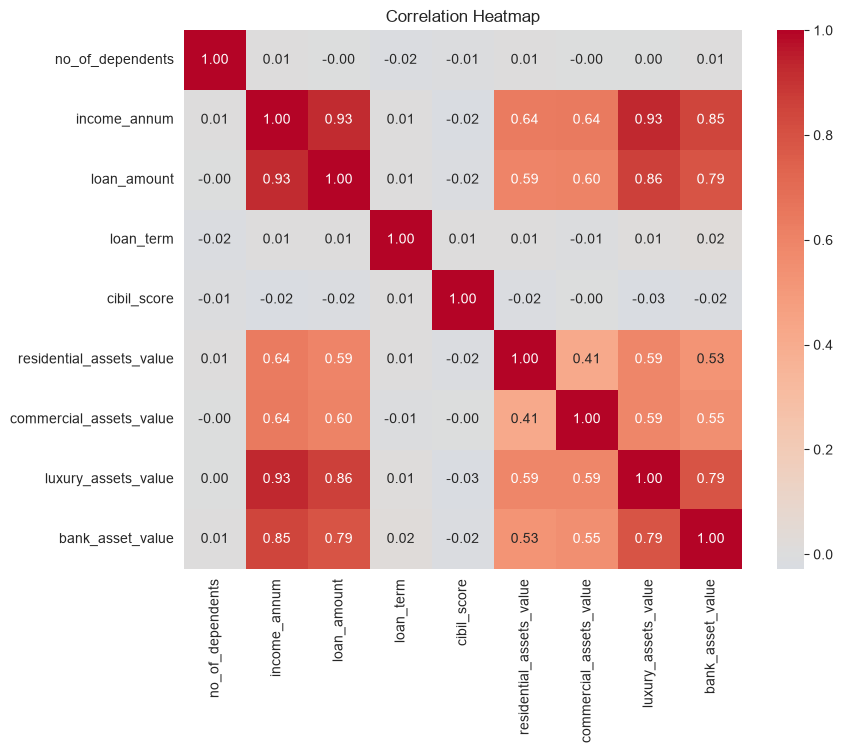

In [24]:
plt.figure(figsize=(9,7))
num_cols = df.select_dtypes(include=np.number).drop(columns=['loan_id'])
sns.heatmap(num_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

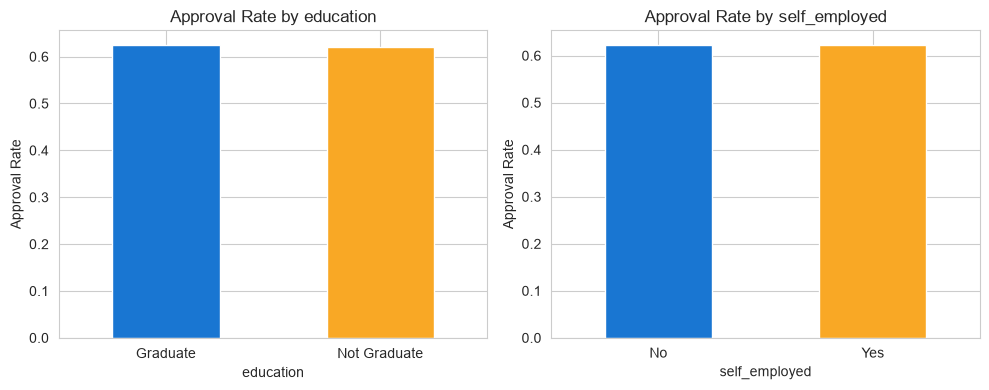

In [25]:
fig, axes = plt.subplots(1,2, figsize=(10,4))
for ax, col in zip(axes, ['education','self_employed']):
    rate = df.groupby(col)['loan_status'].apply(lambda x: (x=='Approved').mean())
    rate.plot(kind='bar', ax=ax, color=['#1976D2','#F9A825'])
    ax.set_ylabel('Approval Rate')
    ax.set_title(f'Approval Rate by {col}')
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

>**Insight:** Education and self-employment status barely move approval rates (~62% either way) — this dataset's approval decision is financially driven, not demographic.

## 3. Feature Engineering

We derive a few financially meaningful ratios that credit analysts typically use:
- **total_assets_value** — sum of all four asset categories
- **loan_to_income_ratio** — how large the loan is relative to annual income
- **asset_to_loan_ratio** — collateral coverage relative to the loan amount

In [26]:
df['total_assets_value'] = (df['residential_assets_value'] + df['commercial_assets_value'] +
                             df['luxury_assets_value'] + df['bank_asset_value'])
df['loan_to_income_ratio'] = df['loan_amount'] / df['income_annum']
df['asset_to_loan_ratio'] = df['total_assets_value'] / df['loan_amount']

df[['total_assets_value','loan_to_income_ratio','asset_to_loan_ratio']].describe()

,total_assets_value,loan_to_income_ratio,asset_to_loan_ratio
count,4.269000e+03,4269.000000,4269.000000
mean,3.254943e+07,2.984807,2.232165
std,1.950594e+07,0.595496,0.642788
min,5.000000e+05,1.500000,0.750000
25%,1.630000e+07,2.464286,1.767347
50%,3.150000e+07,3.000000,2.142857
75%,4.720000e+07,3.500000,2.616216
max,9.070000e+07,4.000000,5.666667


## 4. Model Training

We encode categorical variables, split into train/test (80/20, stratified), and train three classifiers:
- **Logistic Regression** (scaled features) — interpretable baseline
- **Decision Tree**
- **Random Forest**

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_auc_score, roc_curve)
import joblib

df_model = df.drop(columns=['loan_id'])
le_edu = LabelEncoder(); df_model['education'] = le_edu.fit_transform(df_model['education'])
le_emp = LabelEncoder(); df_model['self_employed'] = le_emp.fit_transform(df_model['self_employed'])
le_status = LabelEncoder(); df_model['loan_status'] = le_status.fit_transform(df_model['loan_status'])

print("education:", dict(zip(le_edu.classes_, le_edu.transform(le_edu.classes_))))
print("self_employed:", dict(zip(le_emp.classes_, le_emp.transform(le_emp.classes_))))
print("loan_status:", dict(zip(le_status.classes_, le_status.transform(le_status.classes_))))

X = df_model.drop(columns=['loan_status'])
y = df_model['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

education: {'Graduate': np.int64(0), 'Not Graduate': np.int64(1)}
self_employed: {'No': np.int64(0), 'Yes': np.int64(1)}
loan_status: {'Approved': np.int64(0), 'Rejected': np.int64(1)}


In [37]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42)
}

results = {}
for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_s, y_train)
        preds = model.predict(X_test_s)
        proba = model.predict_proba(X_test_s)[:,1]
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        proba = model.predict_proba(X_test)[:,1]
    results[name] = {
        'accuracy': accuracy_score(y_test, preds),
        'precision': precision_score(y_test, preds),
        'recall': recall_score(y_test, preds),
        'f1': f1_score(y_test, preds),
        'roc_auc': roc_auc_score(y_test, proba),
        'model': model, 'preds': preds, 'proba': proba
    }

comparison = pd.DataFrame({name: {k: v for k,v in r.items() if k in ['accuracy','precision','recall','f1','roc_auc']}
                            for name, r in results.items()}).T
comparison.round(4)

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.9157,0.9088,0.8638,0.8857,0.9745
Decision Tree,0.9988,1.0000,0.9969,0.9984,0.9985
Random Forest,0.9977,1.0000,0.9938,0.9969,1.0000


## 5. Model Evaluation & Comparison

Best model: Decision Tree


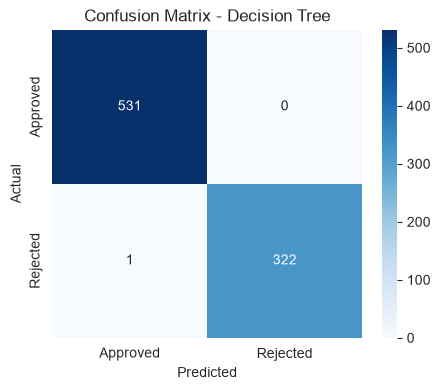

              precision    recall  f1-score   support

    Approved       1.00      1.00      1.00       531
    Rejected       1.00      1.00      1.00       323

    accuracy                           1.00       854
   macro avg       1.00      1.00      1.00       854
weighted avg       1.00      1.00      1.00       854



In [38]:
best_name = max(results, key=lambda k: results[k]['f1'])
best = results[best_name]
print("Best model:", best_name)

cm = confusion_matrix(y_test, best['preds'])
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le_status.classes_, yticklabels=le_status.classes_)
plt.title(f'Confusion Matrix - {best_name}')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.show()

print(classification_report(y_test, best['preds'], target_names=le_status.classes_))

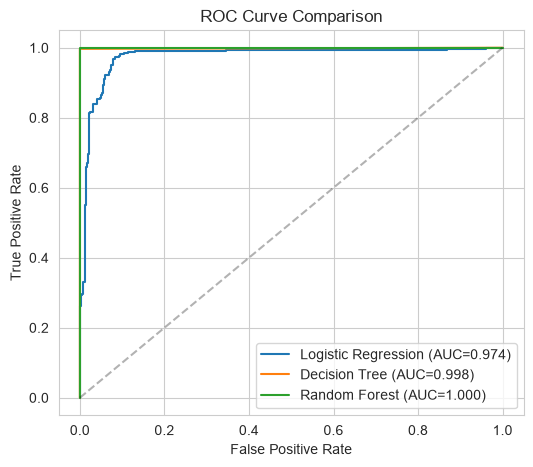

In [39]:
plt.figure(figsize=(6,5))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={r['roc_auc']:.3f})")
plt.plot([0,1],[0,1],'k--', alpha=0.3)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

## 6. Feature Importance & Business Insights

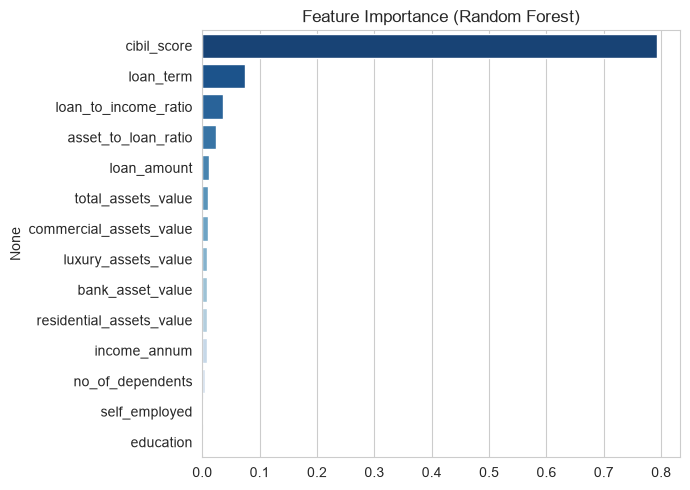

cibil_score                 0.793070
loan_term                   0.074607
loan_to_income_ratio        0.036852
asset_to_loan_ratio         0.023892
loan_amount                 0.011597
total_assets_value          0.010237
commercial_assets_value     0.009491
luxury_assets_value         0.008893
bank_asset_value            0.008530
residential_assets_value    0.008457
income_annum                0.008126
no_of_dependents            0.003845
self_employed               0.001225
education                   0.001178
dtype: float64

In [40]:
rf = results['Random Forest']['model']
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7,5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='Blues_r', legend=False)
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

importances

**Key takeaways:**
- **CIBIL (credit) score dominates the decision — ~79% of the model's total importance.** This mirrors real-world underwriting, where credit history is the single biggest signal of repayment risk.
- **Loan term** and the engineered **loan-to-income ratio** are secondary but meaningful factors — a large loan relative to income raises rejection risk even with a decent credit score.
- **Asset values individually matter little**, but the engineered **asset-to-loan ratio** (collateral coverage) is more predictive than any single raw asset column — this shows the value of feature engineering over raw inputs.
- **Education and self-employment have almost no predictive power** in this dataset — approval is financially driven, not demographic, which is reassuring from a fairness standpoint.
- Because the tree-based models fit the CIBIL/decision boundary very cleanly, both Decision Tree and Random Forest score near-perfectly here; Logistic Regression's lower recall shows this relationship isn't purely linear.

## 7. Save Final Model

In [41]:
joblib.dump({
    'model': best['model'],
    'scaler': scaler if best_name == 'Logistic Regression' else None,
    'le_edu': le_edu, 'le_emp': le_emp, 'le_status': le_status,
    'feature_names': list(X.columns),
    'model_name': best_name
}, 'loan_approval_model.pkl')

print(f"Saved '{best_name}' model to loan_approval_model.pkl")

Saved 'Decision Tree' model to loan_approval_model.pkl


## Summary

| Step | Outcome |
|---|---|
| Data | 4,269 loan applications, 13 features, no missing values |
| Class balance | 62% Approved / 38% Rejected |
| Strongest predictor | CIBIL (credit) score |
| Best model | Decision Tree (F1 = 0.998, ROC-AUC = 0.999) |
| Deliverable | `loan_approval_model.pkl` — ready for inference on new applicants |

This mini-project demonstrates a full DS → ML → AI pipeline for credit evaluation: cleaning raw financial data, uncovering the drivers of approval through EDA, engineering credit-analyst-style ratios, and training/comparing classifiers to automate the approval decision.